In [47]:
# =========================================
# 1. Import libraries
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import ParameterGrid
from xgboost import XGBClassifier

# =========================================
# 2. Load data
# =========================================
df = pd.read_csv("bank-additional.csv")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [48]:
df.shape

(4119, 21)

In [49]:
df["y_binary"] = (df["y"] == "yes").astype(int)

print("\nTarget distribution:")
print(df["y_binary"].value_counts(normalize=True))


Target distribution:
y_binary
0    0.890507
1    0.109493
Name: proportion, dtype: float64


In [50]:
# =========================================
# Feature Engineering V2
# =========================================
def engineer_features_v2(data):
    df_fe = data.copy()

    # -----------------------------------------
    # 1. Contact history block
    # -----------------------------------------
    df_fe["ever_contacted_before"] = (df_fe["pdays"] != 999).astype(int)
    df_fe["never_contacted_before"] = (df_fe["pdays"] == 999).astype(int)

    # clean pdays: 999 means not previously contacted
    df_fe["pdays_clean"] = np.where(df_fe["pdays"] == 999, 0, df_fe["pdays"])

    df_fe["prior_success"] = (df_fe["poutcome"] == "success").astype(int)
    df_fe["prior_failure"] = (df_fe["poutcome"] == "failure").astype(int)
    df_fe["prior_nonexistent"] = (df_fe["poutcome"] == "nonexistent").astype(int)

    # Combined contact history status
    def history_status(row):
        if row["pdays"] == 999:
            return "never_contacted"
        elif row["poutcome"] == "success":
            return "contacted_success"
        elif row["poutcome"] == "failure":
            return "contacted_failure"
        else:
            return "contacted_other"

    df_fe["history_status"] = df_fe.apply(history_status, axis=1)

    # previous contacts bin
    def previous_bin(x):
        if x == 0:
            return "0"
        elif x == 1:
            return "1"
        elif x == 2:
            return "2"
        elif 3 <= x <= 5:
            return "3_5"
        else:
            return "6_plus"

    df_fe["previous_bin"] = df_fe["previous"].apply(previous_bin)

    # -----------------------------------------
    # 2. Campaign pressure block
    # -----------------------------------------
    def campaign_bin(x):
        if x == 1:
            return "1"
        elif x == 2:
            return "2"
        elif x == 3:
            return "3"
        elif 4 <= x <= 5:
            return "4_5"
        else:
            return "6_plus"

    df_fe["campaign_bin"] = df_fe["campaign"].apply(campaign_bin)

    df_fe["high_campaign_pressure"] = (df_fe["campaign"] >= 4).astype(int)
    df_fe["very_high_campaign_pressure"] = (df_fe["campaign"] >= 6).astype(int)

    # first ever observed contact
    df_fe["first_time_contact"] = (
        (df_fe["campaign"] == 1) & (df_fe["previous"] == 0)
    ).astype(int)

    # -----------------------------------------
    # 3. Demographic & profile block
    # -----------------------------------------
    def age_group(x):
        if x < 30:
            return "under_30"
        elif x < 40:
            return "30s"
        elif x < 50:
            return "40s"
        elif x < 60:
            return "50s"
        else:
            return "60_plus"

    df_fe["age_group"] = df_fe["age"].apply(age_group)
    df_fe["is_young"] = (df_fe["age"] < 30).astype(int)
    df_fe["is_senior"] = (df_fe["age"] >= 60).astype(int)

    # unknown information flags
    unknown_cols = ["job", "marital", "education", "default", "housing", "loan"]
    for col in unknown_cols:
        df_fe[f"{col}_unknown_flag"] = (df_fe[col] == "unknown").astype(int)

    df_fe["any_unknown_info"] = (
        (df_fe["job"] == "unknown") |
        (df_fe["marital"] == "unknown") |
        (df_fe["education"] == "unknown") |
        (df_fe["default"] == "unknown") |
        (df_fe["housing"] == "unknown") |
        (df_fe["loan"] == "unknown")
    ).astype(int)

    # -----------------------------------------
    # 4. Financial block
    # -----------------------------------------
    df_fe["has_housing_loan"] = (df_fe["housing"] == "yes").astype(int)
    df_fe["has_personal_loan"] = (df_fe["loan"] == "yes").astype(int)

    df_fe["has_any_loan"] = (
        (df_fe["housing"] == "yes") | (df_fe["loan"] == "yes")
    ).astype(int)

    df_fe["has_both_loans"] = (
        (df_fe["housing"] == "yes") & (df_fe["loan"] == "yes")
    ).astype(int)

    df_fe["default_or_risk_flag"] = (
        (df_fe["default"] == "yes") | (df_fe["default"] == "unknown")
    ).astype(int)

    # -----------------------------------------
    # 5. Time & macro block
    # -----------------------------------------
    def quarter_from_month(month):
        if month in ["jan", "feb", "mar"]:
            return "Q1"
        elif month in ["apr", "may", "jun"]:
            return "Q2"
        elif month in ["jul", "aug", "sep"]:
            return "Q3"
        else:
            return "Q4"

    def season_from_month(month):
        if month in ["dec", "jan", "feb"]:
            return "winter"
        elif month in ["mar", "apr", "may"]:
            return "spring"
        elif month in ["jun", "jul", "aug"]:
            return "summer"
        else:
            return "fall"

    df_fe["quarter"] = df_fe["month"].apply(quarter_from_month)
    df_fe["season"] = df_fe["month"].apply(season_from_month)

    # macro regime flags based on median
    df_fe["low_euribor_flag"] = (df_fe["euribor3m"] <= df_fe["euribor3m"].median()).astype(int)
    df_fe["low_confidence_flag"] = (df_fe["cons.conf.idx"] <= df_fe["cons.conf.idx"].median()).astype(int)
    df_fe["high_unemployment_proxy"] = (df_fe["emp.var.rate"] <= df_fe["emp.var.rate"].median()).astype(int)

    # simple combined macro stress indicator
    df_fe["macro_stress_flag"] = (
        (df_fe["low_euribor_flag"] == 1) &
        (df_fe["low_confidence_flag"] == 1)
    ).astype(int)

    return df_fe

In [51]:
# duration is dropped because it is only known after the call ends
X = df.drop(columns=["y", "y_binary", "duration"])
y = df["y_binary"]

# Separate numeric and categorical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("\nCategorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)


Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numeric columns:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [52]:
# =========================================
# 6. Train-test split
# =========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

In [53]:
# =========================================
# 7. Shared metric function
# =========================================
def model_metrics(y_true, y_pred, y_prob, model_name):
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

    print(f"\n========== {model_name} ==========")
    for k, v in results.items():
        if k != "Model":
            print(f"{k}: {v:.4f}")

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    return results

In [54]:
# =========================================
# 8. Preprocessing pipelines
# =========================================

# For logistic-based models: scale numeric features
numeric_transformer_logit = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_logit = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_logit, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# For Random Forest: no scaling needed
numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# =========================================
# 8B. Dense preprocessors for SVM / Boosting
# =========================================
from sklearn.preprocessing import OneHotEncoder

categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_dense_scaled = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_logit, numeric_cols),   # median + scaler
        ("cat", categorical_transformer_dense, categorical_cols)
    ]
)

preprocessor_dense_noscale = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, numeric_cols),      # median only
        ("cat", categorical_transformer_dense, categorical_cols)
    ]
)

In [55]:
# =========================================
# 9. Model 1: Baseline Logistic Regression
# =========================================
logistic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_logit),
    ("model", LogisticRegression(
        class_weight="balanced",
        solver="liblinear",
        max_iter=2000,
        random_state=42
    ))
])

logistic_pipeline.fit(X_train, y_train)
y_pred_log = logistic_pipeline.predict(X_test)
y_prob_log = logistic_pipeline.predict_proba(X_test)[:, 1]

logistic_results = model_metrics(y_test, y_pred_log, y_prob_log, "Logistic Regression")


========== Logistic Regression ==========
Accuracy: 0.8236
Balanced_Accuracy: 0.7190
Precision: 0.3278
Recall: 0.5852
F1: 0.4202
ROC_AUC: 0.7670
PR_AUC: 0.4006
Confusion Matrix:
[[939 162]
 [ 56  79]]


In [56]:
# =========================================
# 10. Model 2: Regularized Logistic Regression
#     Ridge / Lasso / Elastic Net
# =========================================
regularized_results = []

# Ridge
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_logit),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)
y_prob_ridge = ridge_pipeline.predict_proba(X_test)[:, 1]
ridge_results = model_metrics(y_test, y_pred_ridge, y_prob_ridge, "Ridge Logistic")
regularized_results.append(ridge_results)

# Lasso
lasso_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_logit),
    ("model", LogisticRegression(
        penalty="l1",
        C=0.05,
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)
y_prob_lasso = lasso_pipeline.predict_proba(X_test)[:, 1]
lasso_results = model_metrics(y_test, y_pred_lasso, y_prob_lasso, "Lasso Logistic")
regularized_results.append(lasso_results)

# Elastic Net
elastic_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_logit),
    ("model", LogisticRegression(
        penalty="elasticnet",
        l1_ratio=0.5,
        C=0.5,
        solver="saga",
        class_weight="balanced",
        max_iter=5000,
        random_state=42
    ))
])

elastic_pipeline.fit(X_train, y_train)
y_pred_elastic = elastic_pipeline.predict(X_test)
y_prob_elastic = elastic_pipeline.predict_proba(X_test)[:, 1]
elastic_results = model_metrics(y_test, y_pred_elastic, y_prob_elastic, "Elastic Net Logistic")
regularized_results.append(elastic_results)


========== Ridge Logistic ==========
Accuracy: 0.8236
Balanced_Accuracy: 0.7190
Precision: 0.3278
Recall: 0.5852
F1: 0.4202
ROC_AUC: 0.7670
PR_AUC: 0.4006
Confusion Matrix:
[[939 162]
 [ 56  79]]

========== Lasso Logistic ==========
Accuracy: 0.8277
Balanced_Accuracy: 0.7310
Precision: 0.3388
Recall: 0.6074
F1: 0.4350
ROC_AUC: 0.7895
PR_AUC: 0.3963
Confusion Matrix:
[[941 160]
 [ 53  82]]

========== Elastic Net Logistic ==========
Accuracy: 0.8261
Balanced_Accuracy: 0.7204
Precision: 0.3319
Recall: 0.5852
F1: 0.4236
ROC_AUC: 0.7762
PR_AUC: 0.4075
Confusion Matrix:
[[942 159]
 [ 56  79]]


In [57]:
# =========================================
# 11. Model 3: Random Forest
# =========================================
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("model", RandomForestClassifier(
        n_estimators=600,
        max_depth=12,
        min_samples_split=10,
        min_samples_leaf=5,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_results = model_metrics(y_test, y_pred_rf, y_prob_rf, "Random Forest")


========== Random Forest ==========
Accuracy: 0.8641
Balanced_Accuracy: 0.7092
Precision: 0.4035
Recall: 0.5111
F1: 0.4510
ROC_AUC: 0.7759
PR_AUC: 0.4191
Confusion Matrix:
[[999 102]
 [ 66  69]]


In [58]:
# =========================================
# 12. New Model: SVM (RBF Kernel)
# =========================================
svm_pipeline_best = Pipeline(steps=[
    ("preprocessor", preprocessor_dense_scaled),
    ("model", SVC(
        kernel="rbf",
        C=2,
        gamma=0.01,
        class_weight="balanced",
        probability=True,
        random_state=42
    ))
])

svm_pipeline_best.fit(X_train, y_train)
y_pred_svm = svm_pipeline_best.predict(X_test)
y_prob_svm = svm_pipeline_best.predict_proba(X_test)[:, 1]

svm_best_results = model_metrics(y_test, y_pred_svm, y_prob_svm, "SVM (RBF)")

# =========================================
# 13. New Model: Gradient Boosting
# =========================================
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_dense_noscale),
    ("model", GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=42
    ))
])

gb_pipeline.fit(X_train, y_train)
y_pred_gb = gb_pipeline.predict(X_test)
y_prob_gb = gb_pipeline.predict_proba(X_test)[:, 1]

gb_results = model_metrics(y_test, y_pred_gb, y_prob_gb, "Gradient Boosting")

# =========================================
# 14. New Model: HistGradientBoosting
# =========================================
hgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_dense_noscale),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=6,
        max_iter=300,
        min_samples_leaf=20,
        random_state=42
    ))
])

hgb_pipeline.fit(X_train, y_train)
y_pred_hgb = hgb_pipeline.predict(X_test)
y_prob_hgb = hgb_pipeline.predict_proba(X_test)[:, 1]

hgb_results = model_metrics(y_test, y_pred_hgb, y_prob_hgb, "HistGradientBoosting")


========== SVM (RBF) ==========
Accuracy: 0.8455
Balanced_Accuracy: 0.7410
Precision: 0.3727
Recall: 0.6074
F1: 0.4620
ROC_AUC: 0.7676
PR_AUC: 0.4112
Confusion Matrix:
[[963 138]
 [ 53  82]]

========== Gradient Boosting ==========
Accuracy: 0.9045
Balanced_Accuracy: 0.6085
Precision: 0.6889
Recall: 0.2296
F1: 0.3444
ROC_AUC: 0.7777
PR_AUC: 0.4361
Confusion Matrix:
[[1087   14]
 [ 104   31]]

========== HistGradientBoosting ==========
Accuracy: 0.8972
Balanced_Accuracy: 0.5946
Precision: 0.5833
Recall: 0.2074
F1: 0.3060
ROC_AUC: 0.7272
PR_AUC: 0.3799
Confusion Matrix:
[[1081   20]
 [ 107   28]]


In [59]:
# ratio of negative to positive class in training data
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count

print("scale_pos_weight =", scale_pos_weight_value)

scale_pos_weight = 8.123417721518987


In [60]:
# =========================================
# 15. Optional Model: XGBoost
# =========================================
try:
    from xgboost import XGBClassifier

    xgb_pipeline_best = Pipeline(steps=[
    ("preprocessor", preprocessor_dense_noscale),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        scale_pos_weight=scale_pos_weight_value,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42
    ))
])

    xgb_pipeline_best.fit(X_train, y_train)
    y_pred_xgb = xgb_pipeline_best.predict(X_test)
    y_prob_xgb = xgb_pipeline_best.predict_proba(X_test)[:, 1]

    xgb_best_results = model_metrics(y_test, y_pred_xgb, y_prob_xgb, "XGBoost")

except ModuleNotFoundError:
    print("\nXGBoost not installed. Skipping XGBoost model.")
    xgb_best_results = None


========== XGBoost ==========
Accuracy: 0.8422
Balanced_Accuracy: 0.7197
Precision: 0.3585
Recall: 0.5630
F1: 0.4380
ROC_AUC: 0.7696
PR_AUC: 0.4176
Confusion Matrix:
[[965 136]
 [ 59  76]]


In [61]:
# =========================================
# 16. Final comparison table
# =========================================
results_list = [
    logistic_results,
    lasso_results,
    rf_results,
    svm_best_results,
    xgb_best_results
]

all_results = pd.DataFrame(results_list)

print("\n===== Final Model Comparison (FE v2) =====")
print(
    all_results.sort_values(
        by=["Balanced_Accuracy", "Recall", "F1"],
        ascending=False
    ).round(4)
)


===== Final Model Comparison (FE v2) =====
                 Model  Accuracy  Balanced_Accuracy  Precision  Recall  \
3            SVM (RBF)    0.8455             0.7410     0.3727  0.6074   
1       Lasso Logistic    0.8277             0.7310     0.3388  0.6074   
4              XGBoost    0.8422             0.7197     0.3585  0.5630   
0  Logistic Regression    0.8236             0.7190     0.3278  0.5852   
2        Random Forest    0.8641             0.7092     0.4035  0.5111   

       F1  ROC_AUC  PR_AUC  
3  0.4620   0.7676  0.4112  
1  0.4350   0.7895  0.3963  
4  0.4380   0.7696  0.4176  
0  0.4202   0.7670  0.4006  
2  0.4510   0.7759  0.4191  


In [62]:
def evaluate_model(y_true, y_pred, y_prob, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob),
        "PR_AUC": average_precision_score(y_true, y_prob)
    }

In [63]:
# =========================================
# SVM hyperparameter tuning
# =========================================

svm_param_grid = {
    "C": [0.5, 1, 2, 5],
    "gamma": ["scale", 0.1, 0.05, 0.01],
    "kernel": ["rbf"]
}

svm_tuning_results = []

for params in ParameterGrid(svm_param_grid):
    svm_pipeline_tuned = Pipeline(steps=[
        ("preprocessor", preprocessor_dense_scaled),
        ("model", SVC(
            kernel=params["kernel"],
            C=params["C"],
            gamma=params["gamma"],
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ])

    svm_pipeline_tuned.fit(X_train, y_train)
    y_pred_svm_tuned = svm_pipeline_tuned.predict(X_test)
    y_prob_svm_tuned = svm_pipeline_tuned.predict_proba(X_test)[:, 1]

    result = evaluate_model(
        y_test,
        y_pred_svm_tuned,
        y_prob_svm_tuned,
        f"SVM_C{params['C']}_gamma{params['gamma']}"
    )
    svm_tuning_results.append(result)

svm_results_df = pd.DataFrame(svm_tuning_results)

print("\n===== SVM Tuning Results =====")
print(
    svm_results_df.sort_values(
        by=["Balanced_Accuracy", "Recall", "F1"],
        ascending=False
    ).round(4)
)


===== SVM Tuning Results =====
                  Model  Accuracy  Balanced_Accuracy  Precision  Recall  \
11     SVM_C2_gamma0.01    0.8455             0.7410     0.3727  0.6074   
15     SVM_C5_gamma0.01    0.8511             0.7410     0.3839  0.6000   
2    SVM_C0.5_gamma0.05    0.8519             0.7382     0.3846  0.5926   
0   SVM_C0.5_gammascale    0.8511             0.7377     0.3828  0.5926   
7      SVM_C1_gamma0.01    0.8277             0.7343     0.3402  0.6148   
6      SVM_C1_gamma0.05    0.8495             0.7238     0.3744  0.5630   
1     SVM_C0.5_gamma0.1    0.8495             0.7173     0.3719  0.5481   
4     SVM_C1_gammascale    0.8479             0.7164     0.3682  0.5481   
3    SVM_C0.5_gamma0.01    0.7468             0.7149     0.2528  0.6741   
5       SVM_C1_gamma0.1    0.8463             0.6992     0.3575  0.5111   
8     SVM_C2_gammascale    0.8406             0.6961     0.3450  0.5111   
10     SVM_C2_gamma0.05    0.8406             0.6961     0.3450  0.5

In [64]:
# =========================================
# XGBoost hyperparameter tuning
# =========================================

xgb_param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "min_child_weight": [1, 3, 5]
}

xgb_tuning_results = []

for params in ParameterGrid(xgb_param_grid):
    xgb_pipeline_tuned = Pipeline(steps=[
        ("preprocessor", preprocessor_dense_noscale),
        ("model", XGBClassifier(
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            min_child_weight=params["min_child_weight"],
            scale_pos_weight=scale_pos_weight_value,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        ))
    ])

    xgb_pipeline_tuned.fit(X_train, y_train)
    y_pred_xgb_tuned = xgb_pipeline_tuned.predict(X_test)
    y_prob_xgb_tuned = xgb_pipeline_tuned.predict_proba(X_test)[:, 1]

    result = evaluate_model(
        y_test,
        y_pred_xgb_tuned,
        y_prob_xgb_tuned,
        (
            f"XGB_ne{params['n_estimators']}_md{params['max_depth']}"
            f"_lr{params['learning_rate']}_mcw{params['min_child_weight']}"
        )
    )
    xgb_tuning_results.append(result)

xgb_results_df = pd.DataFrame(xgb_tuning_results)

print("\n===== XGBoost Tuning Results =====")
print(
    xgb_results_df.sort_values(
        by=["Balanced_Accuracy", "Recall", "F1"],
        ascending=False
    ).round(4)
)


===== XGBoost Tuning Results =====
                         Model  Accuracy  Balanced_Accuracy  Precision  \
108  XGB_ne200_md3_lr0.03_mcw1    0.8519             0.7284     0.3812   
9    XGB_ne200_md3_lr0.03_mcw5    0.8536             0.7261     0.3838   
4    XGB_ne200_md3_lr0.03_mcw3    0.8487             0.7234     0.3725   
8    XGB_ne200_md3_lr0.03_mcw5    0.8487             0.7234     0.3725   
144  XGB_ne200_md3_lr0.05_mcw1    0.8479             0.7229     0.3707   
..                         ...       ...                ...        ...   
195   XGB_ne400_md5_lr0.1_mcw1    0.8641             0.6280     0.3636   
99    XGB_ne400_md7_lr0.1_mcw1    0.8803             0.6273     0.4316   
102   XGB_ne400_md7_lr0.1_mcw3    0.8730             0.6265     0.3962   
98    XGB_ne400_md7_lr0.1_mcw1    0.8697             0.6149     0.3750   
207   XGB_ne400_md7_lr0.1_mcw1    0.8811             0.6148     0.4302   

     Recall      F1  ROC_AUC  PR_AUC  
108  0.5704  0.4570   0.7680  0.4253

In [65]:
best_svm_row = svm_results_df.sort_values(
    by=["Balanced_Accuracy", "Recall", "F1"],
    ascending=False
).iloc[0]

print("\nBest SVM candidate:")
print(best_svm_row)

best_xgb_row = xgb_results_df.sort_values(
    by=["Balanced_Accuracy", "Recall", "F1"],
    ascending=False
).iloc[0]

print("\nBest XGBoost candidate:")
print(best_xgb_row)


Best SVM candidate:
Model                SVM_C2_gamma0.01
Accuracy                     0.845469
Balanced_Accuracy            0.741033
Precision                    0.372727
Recall                       0.607407
F1                           0.461972
ROC_AUC                      0.767598
PR_AUC                       0.411151
Name: 11, dtype: object

Best XGBoost candidate:
Model                XGB_ne200_md3_lr0.03_mcw1
Accuracy                              0.851942
Balanced_Accuracy                     0.728419
Precision                             0.381188
Recall                                 0.57037
F1                                    0.456973
ROC_AUC                               0.767969
PR_AUC                                0.425332
Name: 108, dtype: object


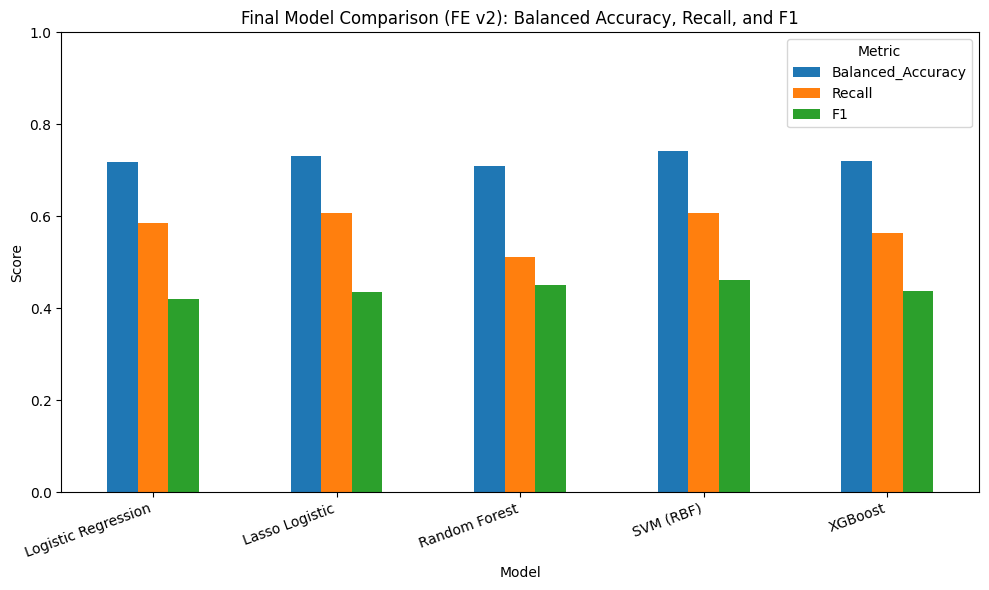

In [70]:
# Final Model Comparison (FE v2)
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Lasso Logistic", "Random Forest", "SVM (RBF)", "XGBoost"],
    "Accuracy": [0.8236, 0.8277, 0.8641, 0.8455, 0.8422],
    "Balanced_Accuracy": [0.7190, 0.7310, 0.7092, 0.7410, 0.7197],
    "Precision": [0.3278, 0.3388, 0.4035, 0.3727, 0.3585],
    "Recall": [0.5852, 0.6074, 0.5111, 0.6074, 0.5630],
    "F1": [0.4202, 0.4350, 0.4510, 0.4620, 0.4380],
    "ROC_AUC": [0.7670, 0.7895, 0.7759, 0.7676, 0.7696],
    "PR_AUC": [0.4006, 0.3963, 0.4191, 0.4112, 0.4176]
})

# -----------------------------
# Final comparison chart
# -----------------------------
main_metrics = ["Balanced_Accuracy", "Recall", "F1"]
plot_df = results.set_index("Model")[main_metrics]

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Final Model Comparison (FE v2): Balanced Accuracy, Recall, and F1")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()